## Read customers data

In [2]:
!pip install python-dotenv

  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
Using cached python_dotenv-1.2.2-py3-none-any.whl (22 kB)



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
!pip install anthropic

  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jiter-0.14.0-cp313-cp313-win_amd64.whl.metadata (5.3 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
   ---------------------------------------- 0.0/662.1 kB ? eta -:--:--
   ---------------------------------------- 662.1/662.1 kB 16.4 MB/s  0:00:00
Using cached anyio-4.13.0-py3-none-any.whl (114 kB)
Using cached distro-1.9.0-py3-none-any.whl (20 kB)
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
Using cached jiter-0.14.0-cp313-cp313-win_amd64.w


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
from dotenv import load_dotenv
import os
import anthropic

load_dotenv()
client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))

In [49]:
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# Analyze the customer behavior



*   streak: number of continous win or loss
*   bet: the amount per round
*   payout: how much win at the round (0=lose)



In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("results_superstitious_1.csv")

In [5]:
import pandas as pd
import glob

all_files = glob.glob("results_*.csv")
df_all = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)

print(f"總玩家數: {df_all['player_id'].nunique()}")
print(f"總資料筆數: {len(df_all)}")
print(df_all['persona'].value_counts())

總玩家數: 110
總資料筆數: 15200
persona
superstitious    9001
rational         5238
social            961
Name: count, dtype: int64


In [9]:
import os
print(os.getcwd())
print(glob.glob("results_*.csv"))

c:\Users\Albee\Desktop\Vscode_test_file
['results_rational_1.csv', 'results_rational_2.csv', 'results_social.csv', 'results_superstitious_1.csv', 'results_superstitious_2.csv', 'results_superstitious_3.csv', 'results_superstitious_4.csv', 'results_superstitious_5.csv']


In [8]:
df_all['persona'].value_counts()

persona
superstitious    9001
rational         5238
social            961
Name: count, dtype: int64

In [6]:
df_all.shape

(15200, 13)

In [ ]:
df_all.columns

Index(['persona', 'round', 'bet', 'is_win', 'payout', 'balance', 'reasoning',
       'streak', 'player_id', 'initial_balance', 'income_bracket'],
      dtype='object')

In [ ]:
print(df_all.shape)
print(df_all["persona"].value_counts())

(745, 11)
persona
superstitious    220
impulsive        211
casual           129
addicted         126
rational          59
Name: count, dtype: int64


In [ ]:
# superstitious

df_sup = df_all[ df_all['persona']== 'superstitious' ]
df_casual = df_all[ df_all['persona']== 'casual' ]
df_addicted = df_all[ df_all['persona']== 'addicted' ]
df_impulsive = df_all[ df_all['persona']== 'impulsive' ]
df_rational = df_all[ df_all['persona']== 'rational' ]

In [ ]:
df_sup.describe()

,round,bet,is_win,payout,balance,streak,initial_balance
count,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000
mean,13.300000,38.334091,0.177273,19.665909,126.188636,-2.090909,184.681818
std,15.210877,27.352693,0.382770,53.158641,122.449727,2.245423,138.564785
min,1.000000,5.000000,0.000000,0.000000,0.000000,-9.000000,51.000000
25%,3.000000,15.000000,0.000000,0.000000,36.375000,-3.000000,69.000000
50%,7.000000,25.000000,0.000000,0.000000,87.750000,-2.000000,146.000000
75%,17.250000,50.000000,0.000000,0.000000,181.375000,-1.000000,239.000000
max,61.000000,100.000000,1.000000,250.000000,626.000000,4.000000,498.000000


In [ ]:
df_casual.describe()

,round,bet,is_win,payout,balance,streak,initial_balance
count,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000
mean,4.581395,17.422481,0.193798,17.034884,219.647287,-1.759690,219.395349
std,3.671464,13.012682,0.396814,56.576973,156.701877,1.971576,147.398769
min,1.000000,2.500000,0.000000,0.000000,38.000000,-6.000000,58.000000
25%,2.000000,10.000000,0.000000,0.000000,88.000000,-3.000000,74.000000
50%,4.000000,15.000000,0.000000,0.000000,190.000000,-2.000000,139.000000
75%,6.000000,20.000000,0.000000,0.000000,337.000000,-1.000000,377.000000
max,19.000000,100.000000,1.000000,500.000000,1056.000000,3.000000,484.000000


In [ ]:
df_addicted.describe()

,round,bet,is_win,payout,balance,streak,initial_balance
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,6.626984,74.103175,0.142857,34.833333,231.277778,-2.206349,256.761905
std,6.848923,29.549979,0.351324,122.920950,259.698506,2.380983,146.495293
min,1.000000,10.000000,0.000000,0.000000,0.000000,-12.000000,54.000000
25%,2.000000,50.000000,0.000000,0.000000,50.625000,-3.000000,93.000000
50%,4.000000,89.500000,0.000000,0.000000,148.000000,-2.000000,294.000000
75%,8.750000,100.000000,0.000000,0.000000,330.000000,-1.000000,383.000000
max,29.000000,100.000000,1.000000,1000.000000,1280.000000,2.000000,468.000000


In [ ]:
df_impulsive.describe()

,round,bet,is_win,payout,balance,streak,initial_balance
count,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000
mean,19.616114,79.853081,0.189573,72.206161,592.528436,-2.635071,149.161137
std,22.171400,29.507581,0.392896,209.332491,573.386566,3.071296,133.398125
min,1.000000,4.000000,0.000000,0.000000,0.000000,-13.000000,50.000000
25%,3.000000,50.000000,0.000000,0.000000,114.500000,-4.000000,62.000000
50%,10.000000,100.000000,0.000000,0.000000,417.000000,-2.000000,75.000000
75%,27.500000,100.000000,0.000000,0.000000,917.000000,-1.000000,201.500000
max,80.000000,100.000000,1.000000,1000.000000,2067.000000,3.000000,490.000000


In [ ]:
df_rational.describe()

,round,bet,is_win,payout,balance,streak,initial_balance
count,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000
mean,2.101695,28.983051,0.135593,22.762712,247.389831,-1.457627,284.067797
std,0.977240,13.901428,0.345295,83.823108,143.290911,1.250131,128.667557
min,1.000000,5.000000,0.000000,0.000000,39.000000,-4.000000,54.000000
25%,1.000000,17.500000,0.000000,0.000000,143.750000,-2.000000,192.000000
50%,2.000000,30.000000,0.000000,0.000000,252.000000,-2.000000,317.000000
75%,3.000000,40.000000,0.000000,0.000000,318.000000,-1.000000,377.500000
max,4.000000,50.000000,1.000000,500.000000,820.000000,1.000000,472.000000


In [ ]:
# total bet

df_all.groupby('persona')['round'].count()

,round
persona,
addicted,126
casual,129
impulsive,211
rational,59
superstitious,220


/tmp/ipykernel_4184/3194901405.py:12: FutureWarning: The provided callable <built-in function max> is currently using np.maximum.reduce. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string np.maximum.reduce instead.
  s = df_all.groupby('persona')[feature].apply(func)
/tmp/ipykernel_4184/3194901405.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index)
/tmp/ipykernel_4184/3194901405.py:12: FutureWarning: The provided callable <built-in function min> is currently using np.minimum.reduce. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string np.minimum.reduce instead.
  s = df_all.groupby('persona')[feature].apply(func)
/tmp/ipykernel_4184/3194901405.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_tic

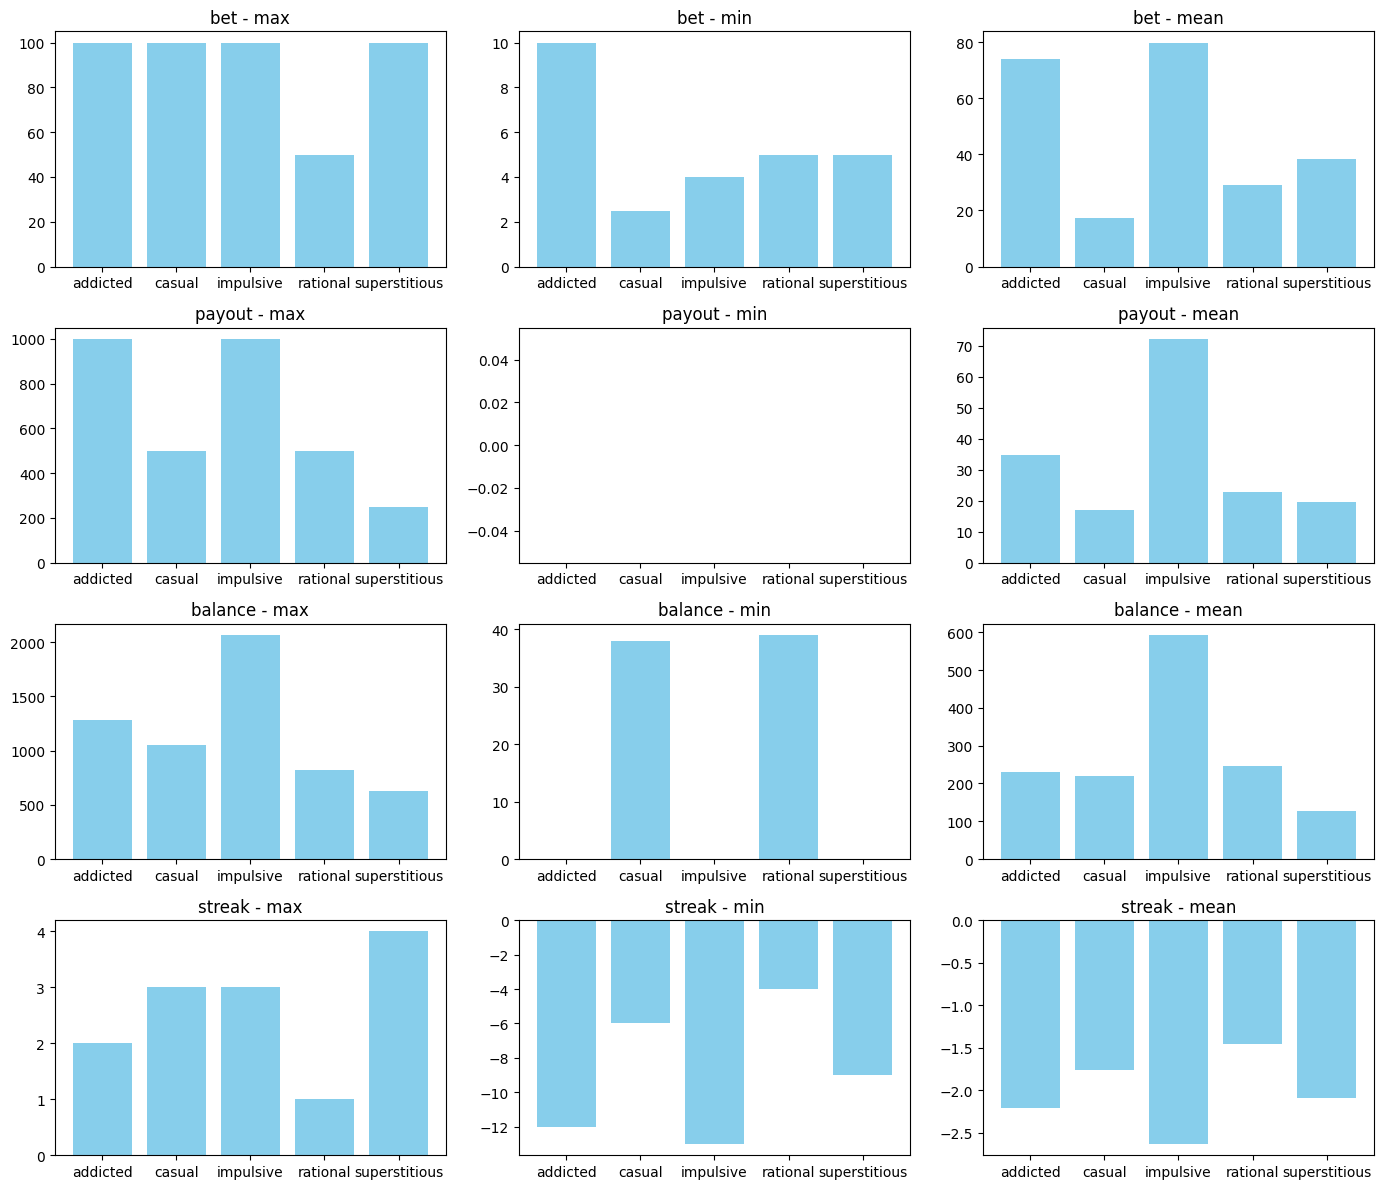

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

list_for_graphs = ['bet', 'payout', 'balance', 'streak']
condition = [max, min, np.mean]

fig, axes = plt.subplots(len(list_for_graphs), len(condition), figsize=(14, 12))

for row, feature in enumerate(list_for_graphs):
    for col, func in enumerate(condition):

        s = df_all.groupby('persona')[feature].apply(func)

        ax = axes[row][col]
        ax.bar(s.index, s.values, color='skyblue')

        ax.set_title(f"{feature} - {func.__name__}")
        ax.set_xticklabels(s.index)

plt.tight_layout()
plt.show()


# Clustering

In [ ]:
print(df_all.shape)
print(df_all["player_id"].nunique())

(745, 11)
100


In [ ]:
df_player = df_all.groupby("player_id").agg(
    persona        = ("persona", "first"),                                     # new column name = ("original column", "agg method")
    income_bracket = ("income_bracket", "first"),
    initial_balance= ("initial_balance", "first"),
    total_rounds   = ("round", "max"),
    avg_bet        = ("bet", "mean"),
    max_bet        = ("bet", "max"),
    win_rate       = ("is_win", "mean"),
    total_payout   = ("payout", "sum"),
    final_balance  = ("balance", "last"),
    avg_streak     = ("streak", "mean"),
    min_streak     = ("streak", "min")
).reset_index()

print(df_player.shape)
print(df_player.head())

(100, 12)
                              player_id        persona income_bracket  \
0  02ac54f2-4377-4f3c-a3d8-dbd07cb5b695      impulsive           High   
1  0312edae-3a3c-4e6b-a031-24623c92af5c  superstitious            Low   
2  048d2c4f-1c23-42c2-8e44-d749f80c814a       addicted            Low   
3  057f7d57-4b89-478d-8dcb-2a79e3da3b99         casual         Medium   
4  06ec53b5-ed96-4090-9eda-80c3df2af9b0  superstitious         Medium   

   initial_balance  total_rounds     avg_bet  max_bet  win_rate  total_payout  \
0              490            16  100.000000    100.0  0.125000        1150.0   
1               69             9   13.500000     15.0  0.222222          52.5   
2               70             3   23.333333     25.0  0.000000           0.0   
3              235             5   20.000000     20.0  0.200000          40.0   
4              113            16   19.781250     30.0  0.250000         203.5   

   final_balance  avg_streak  min_streak  
0           40.0   -2

In [ ]:
df_player.head()

,player_id,persona,income_bracket,initial_balance,total_rounds,avg_bet,max_bet,win_rate,total_payout,final_balance,avg_streak,min_streak
0,02ac54f2-4377-4f3c-a3d8-dbd07cb5b695,impulsive,High,490,16,100.000000,100.0,0.125000,1150.0,40.0,-2.500000,-6
1,0312edae-3a3c-4e6b-a031-24623c92af5c,superstitious,Low,69,9,13.500000,15.0,0.222222,52.5,0.0,-1.666667,-5
2,048d2c4f-1c23-42c2-8e44-d749f80c814a,addicted,Low,70,3,23.333333,25.0,0.000000,0.0,0.0,-2.000000,-3
3,057f7d57-4b89-478d-8dcb-2a79e3da3b99,casual,Medium,235,5,20.000000,20.0,0.200000,40.0,175.0,-1.800000,-4
4,06ec53b5-ed96-4090-9eda-80c3df2af9b0,superstitious,Medium,113,16,19.781250,30.0,0.250000,203.5,0.0,-1.750000,-6


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


features = ["avg_bet", "total_rounds", "final_balance", "avg_streak", "min_streak"]
X = df_player[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

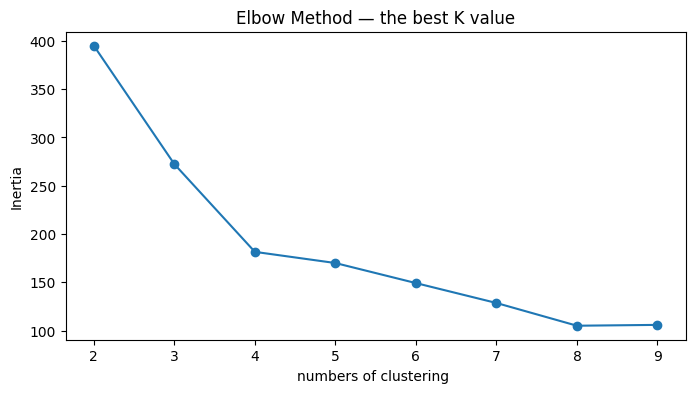

In [ ]:
inertia = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)                                          # fit scaled data
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("numbers of clustering ")
plt.ylabel("Inertia")
plt.title("Elbow Method — the best K value")
plt.show()

In [ ]:
from sklearn.cluster import KMeans

# 跑 K=4, 5, 6
for k in [4, 5, 6]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    df_player[f"cluster_k{k}"] = kmeans.fit_predict(X_scaled)  # produce clustering result (number 1~XXX), assign a variable to it.

# 看每個K值的分群結果
for k in [4, 5, 6]:
    print(f"\n{'='*40}")
    print(f"K={k} 的分群結果：")
    print('='*40)
    print(df_player.groupby(f"cluster_k{k}")[features].mean().round(2))

for k in [4, 5, 6]:
    print(f"\nK={k} 各群人數：")
    print(df_player[f"cluster_k{k}"].value_counts().sort_index())


K=4 的分群結果：
            avg_bet  total_rounds  final_balance  avg_streak  min_streak
cluster_k4                                                              
0             24.47          4.78         103.10       -1.79       -3.38
1             48.07          4.60         905.20        0.28       -1.00
2             65.08         44.60           3.00       -3.04      -11.00
3             77.94          7.33          17.83       -2.30       -4.70

K=5 的分群結果：
            avg_bet  total_rounds  final_balance  avg_streak  min_streak
cluster_k5                                                              
0             22.59          4.81          99.90       -1.79       -3.39
1             48.07          4.60         905.20        0.28       -1.00
2             65.08         44.60           3.00       -3.04      -11.00
3             83.62          8.36          13.23       -2.82       -5.73
4             69.68          6.15          46.85       -1.91       -3.85

K=6 的分群結果：
            avg

In [ ]:
df_player

,player_id,persona,income_bracket,initial_balance,total_rounds,avg_bet,max_bet,win_rate,total_payout,final_balance,avg_streak,min_streak,cluster_k4,cluster_k5,cluster_k6
0,02ac54f2-4377-4f3c-a3d8-dbd07cb5b695,impulsive,High,490,16,100.000000,100.0,0.125000,1150.0,40.0,-2.500000,-6,3,3,3
1,0312edae-3a3c-4e6b-a031-24623c92af5c,superstitious,Low,69,9,13.500000,15.0,0.222222,52.5,0.0,-1.666667,-5,0,0,0
2,048d2c4f-1c23-42c2-8e44-d749f80c814a,addicted,Low,70,3,23.333333,25.0,0.000000,0.0,0.0,-2.000000,-3,0,0,0
3,057f7d57-4b89-478d-8dcb-2a79e3da3b99,casual,Medium,235,5,20.000000,20.0,0.200000,40.0,175.0,-1.800000,-4,0,0,0
4,06ec53b5-ed96-4090-9eda-80c3df2af9b0,superstitious,Medium,113,16,19.781250,30.0,0.250000,203.5,0.0,-1.750000,-6,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,f65a8cb1-3117-4b1f-ab07-6552d125823b,addicted,Low,93,2,35.000000,40.0,0.000000,0.0,23.0,-1.500000,-2,0,0,0
96,f6b9f763-d6b5-4603-b17b-b03acc319310,addicted,High,305,6,77.500000,100.0,0.166667,275.0,115.0,-1.333333,-3,3,4,4
97,f7525ff0-8dd5-45cb-ad23-64aea018747c,casual,High,406,6,25.000000,50.0,0.500000,800.0,1056.0,0.000000,-3,1,1,1
98,f8d5802a-f7ab-442c-b0dc-9bd56c723486,superstitious,High,489,6,81.500000,100.0,0.000000,0.0,0.0,-3.500000,-6,3,3,3


In [ ]:
# give new names of each cluster
cluster_names = {
    0: "Casual Player",
    1: "Lucky Winner",
    2: "Addicted Loser",
    3: "Impulsive Loser"
}

df_player["cluster_name"] = df_player["cluster_k4"].map(cluster_names)

In [ ]:
df_player = df_player.drop(columns = ['cluster_k4' ,'cluster_k5', 'cluster_k6'])

In [ ]:
df_player

,player_id,persona,income_bracket,initial_balance,total_rounds,avg_bet,max_bet,win_rate,total_payout,final_balance,avg_streak,min_streak,cluster_name
0,02ac54f2-4377-4f3c-a3d8-dbd07cb5b695,impulsive,High,490,16,100.000000,100.0,0.125000,1150.0,40.0,-2.500000,-6,Impulsive Loser
1,0312edae-3a3c-4e6b-a031-24623c92af5c,superstitious,Low,69,9,13.500000,15.0,0.222222,52.5,0.0,-1.666667,-5,Casual Player
2,048d2c4f-1c23-42c2-8e44-d749f80c814a,addicted,Low,70,3,23.333333,25.0,0.000000,0.0,0.0,-2.000000,-3,Casual Player
3,057f7d57-4b89-478d-8dcb-2a79e3da3b99,casual,Medium,235,5,20.000000,20.0,0.200000,40.0,175.0,-1.800000,-4,Casual Player
4,06ec53b5-ed96-4090-9eda-80c3df2af9b0,superstitious,Medium,113,16,19.781250,30.0,0.250000,203.5,0.0,-1.750000,-6,Casual Player
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,f65a8cb1-3117-4b1f-ab07-6552d125823b,addicted,Low,93,2,35.000000,40.0,0.000000,0.0,23.0,-1.500000,-2,Casual Player
96,f6b9f763-d6b5-4603-b17b-b03acc319310,addicted,High,305,6,77.500000,100.0,0.166667,275.0,115.0,-1.333333,-3,Impulsive Loser
97,f7525ff0-8dd5-45cb-ad23-64aea018747c,casual,High,406,6,25.000000,50.0,0.500000,800.0,1056.0,0.000000,-3,Lucky Winner
98,f8d5802a-f7ab-442c-b0dc-9bd56c723486,superstitious,High,489,6,81.500000,100.0,0.000000,0.0,0.0,-3.500000,-6,Impulsive Loser


In [ ]:
print(df_player["cluster_name"].value_counts())

cluster_name
Casual Player      63
Impulsive Loser    27
Lucky Winner        5
Addicted Loser      5
Name: count, dtype: int64


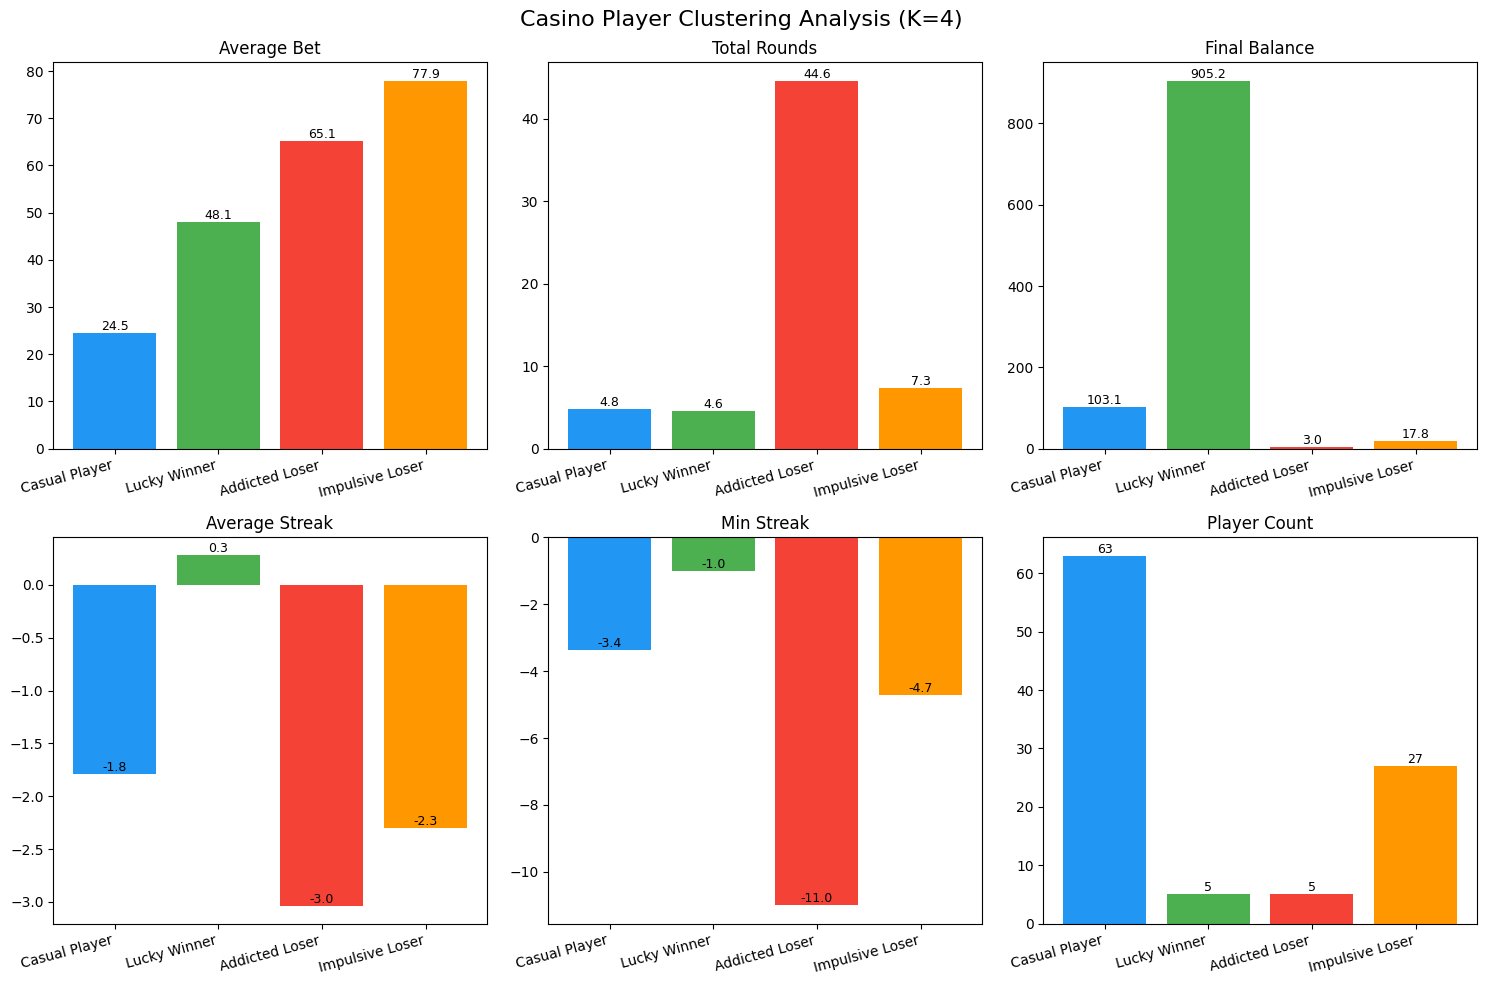

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Casino Player Clustering Analysis (K=4)", fontsize=16)

features_to_plot = ["avg_bet", "total_rounds", "final_balance", "avg_streak", "min_streak"]
titles = ["Average Bet", "Total Rounds", "Final Balance", "Average Streak", "Min Streak"]

cluster_order = ["Casual Player", "Lucky Winner", "Addicted Loser", "Impulsive Loser"]
colors = ["#2196F3", "#4CAF50", "#F44336", "#FF9800"]

for idx, (feature, title) in enumerate(zip(features_to_plot, titles)):
    ax = axes[idx // 3][idx % 3]
    values = [df_player[df_player["cluster_name"] == c][feature].mean() for c in cluster_order]
    bars = ax.bar(cluster_order, values, color=colors)
    ax.set_title(title)
    ax.set_xticklabels(cluster_order, rotation=15, ha="right")

    # 在每個bar上面顯示數字
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{val:.1f}", ha="center", va="bottom", fontsize=9)

# 最後一格顯示人數
ax = axes[1][2]
counts = [df_player[df_player["cluster_name"] == c].shape[0] for c in cluster_order]
bars = ax.bar(cluster_order, counts, color=colors)
ax.set_title("Player Count")
ax.set_xticklabels(cluster_order, rotation=15, ha="right")
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            str(val), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# High-value customer prediction

In [ ]:
df_player["casino_revenue"] = df_player["initial_balance"] - df_player["final_balance"]
df_player["loss_rate"] = df_player["casino_revenue"] / df_player["initial_balance"]
df_player["is_high_value"] = (df_player["loss_rate"] >= 0.6).astype(int)

# 看一下分佈
print(df_player["is_high_value"].value_counts())
print(f"\n高價值玩家比例：{df_player['is_high_value'].mean():.1%}")

is_high_value
1    58
0    42
Name: count, dtype: int64

高價值玩家比例：58.0%


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import root_mean_squared_error  as rmse

# 處理 income_bracket（文字→數字）
le = LabelEncoder()
df_player["income_encoded"] = le.fit_transform(df_player["income_bracket"])

# 準備 features 和 target
features = ["avg_bet", "total_rounds", "avg_streak", "min_streak"]   #"income_encoded" "initial_balance"
X = df_player[features]
y = df_player["is_high_value"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_train)
print(classification_report(y_train, y_pred),'\n','-'*60)
print(rmse(y_train, y_pred))


y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))
print(rmse(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        34
           1       0.98      1.00      0.99        46

    accuracy                           0.99        80
   macro avg       0.99      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80
 
 ------------------------------------------------------------
0.11180339887498948
              precision    recall  f1-score   support

           0       0.60      0.38      0.46         8
           1       0.67      0.83      0.74        12

    accuracy                           0.65        20
   macro avg       0.63      0.60      0.60        20
weighted avg       0.64      0.65      0.63        20

0.5916079783099616


In [ ]:
y_train.value_counts(normalize='True')

,proportion
is_high_value,
1,0.575
0,0.425


In [ ]:
y_test.value_counts(normalize='True')

,proportion
is_high_value,
1,0.6
0,0.4


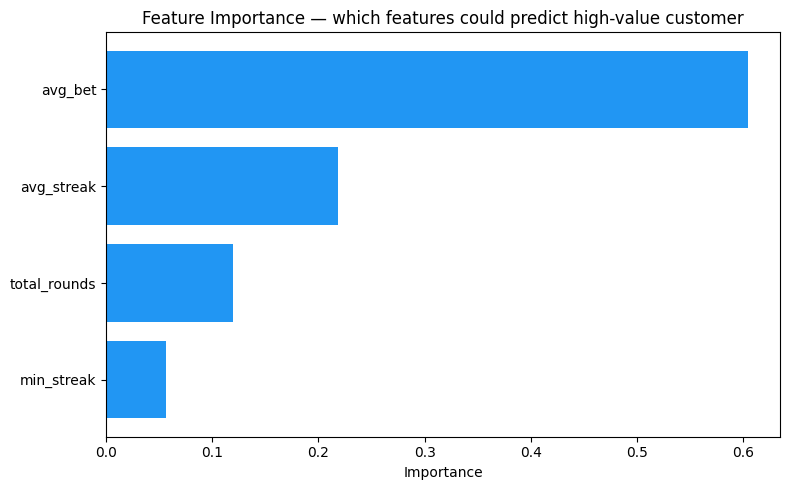

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"], color="#2196F3")
plt.title("Feature Importance — which features could predict high-value customer")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## NLP

###Initial group

In [ ]:
print(df_all["reasoning"].count())
print(df_all["reasoning"].iloc[0])

745
剛來到賭場，心情不錯，先穩穩地下個小注享受一下氣氛吧！


In [ ]:
! pip install jieba

In [ ]:
# 用系統內建的方式安裝中文字體
!apt-get install -y fonts-noto-cjk

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 重新載入字體
fm._load_fontmanager(try_read_cache=False)

# 找到剛安裝的字體
font_path = fm.findfont(fm.FontProperties(family='Noto Sans CJK SC'))
plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()

print("字體設定完成：", plt.rcParams['font.family'])

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Suggested packages:
  fonts-noto-cjk-extra
The following NEW packages will be installed:
  fonts-noto-cjk
0 upgraded, 1 newly installed, 0 to remove and 6 not upgraded.
Need to get 61.2 MB of archives.
After this operation, 93.2 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-cjk all 1:20220127+repack1-1 [61.2 MB]
Fetched 61.2 MB in 2s (24.7 MB/s)
Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


字體設定完成： ['DejaVu Sans']


In [ ]:
!apt-get install -y fonts-noto-cjk -q

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import os

# 找到所有 Noto CJK 字體
fonts = [f for f in fm.findSystemFonts() if 'Noto' in f and 'CJK' in f]
print("找到的字體：", fonts)

Reading package lists...
Building dependency tree...
Reading state information...
fonts-noto-cjk is already the newest version (1:20220127+repack1-1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.
找到的字體： ['/usr/share/fonts/opentype/noto/NotoSerifCJK-Regular.ttc', '/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc', '/usr/share/fonts/opentype/noto/NotoSerifCJK-Bold.ttc', '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc']


In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 直接指定字體路徑
font_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = prop.get_name()

print("字體設定完成：", plt.rcParams['font.family'])

字體設定完成： ['Noto Sans CJK JP']


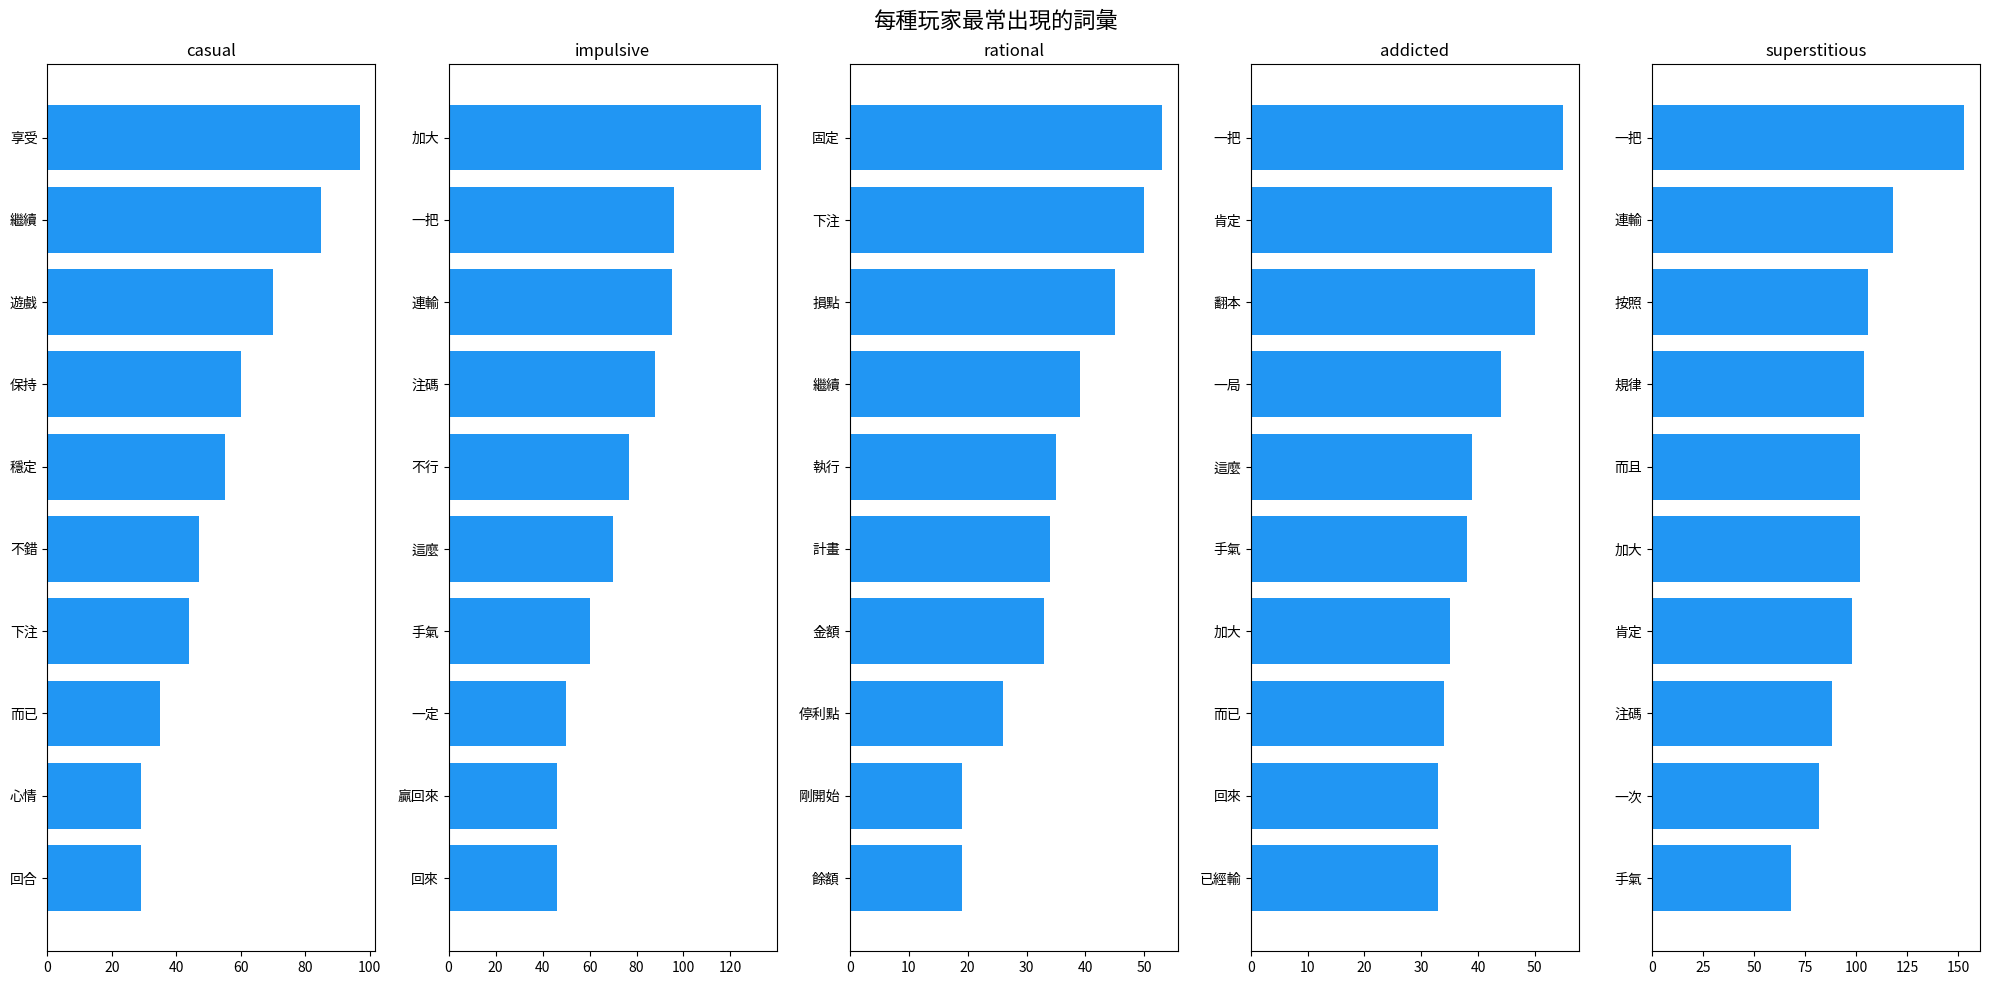

In [ ]:
import jieba
from collections import Counter
import matplotlib.pyplot as plt

# 設定停用詞（這些詞太常見，沒有分析價值）
stopwords = set([
    "我", "的", "了", "是", "在", "也", "就", "都", "而", "及",
    "與", "著", "或", "一", "有", "但", "不", "這", "來", "去",
    "把", "被", "你", "他", "她", "它", "們", "個", "那", "好",
    "吧", "啊", "呢", "嗎", "喔", "哦", "哈", "！", "，", "。",
    "？", "、", "再", "又", "很", "還", "才", "就", "要", "會"
])

# 對每種玩家做詞頻分析
fig, axes = plt.subplots(1, 5, figsize=(20, 10))
personas = ["casual", "impulsive", "rational", "addicted", "superstitious"]

for idx, persona in enumerate(personas):
    # 取出這種玩家的所有 reasoning
    texts = df_all[df_all["persona"] == persona]["reasoning"].dropna()

    # 斷詞
    all_words = []
    for text in texts:
        words = jieba.cut(text)
        for word in words:
            if word not in stopwords and len(word) > 1:
                all_words.append(word)

    # 取前10個最常出現的詞
    top_words = Counter(all_words).most_common(10)
    words, counts = zip(*top_words)

    axes[idx].barh(words, counts, color="#2196F3")
    axes[idx].set_title(persona)
    axes[idx].invert_yaxis()

plt.suptitle("每種玩家最常出現的詞彙", fontsize=16)
plt.tight_layout()
plt.show()

破產玩家數量：45


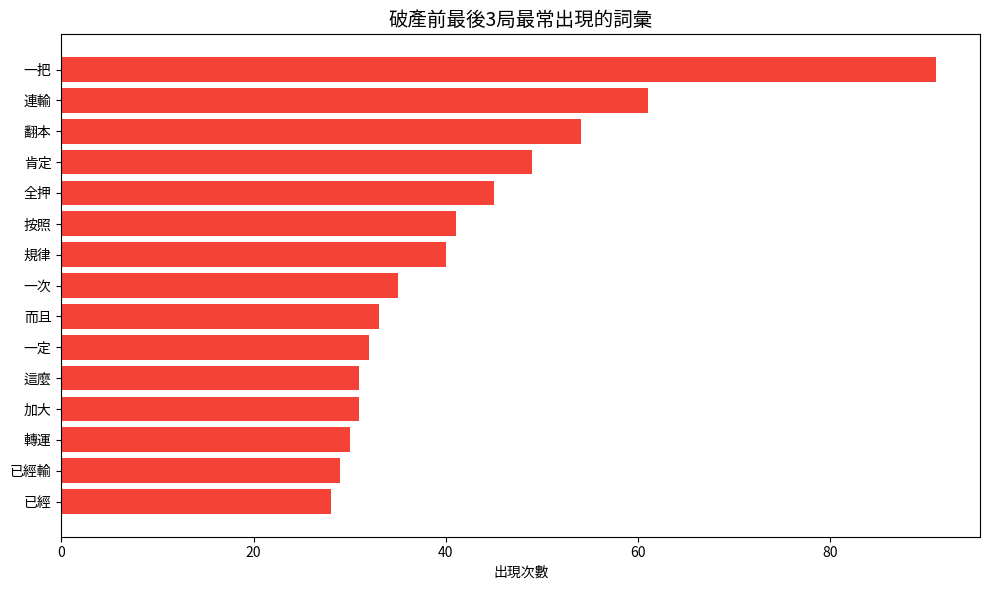

In [ ]:
# 找出破產的玩家（最終餘額為0或接近0）
bankrupt_players = df_player[df_player["final_balance"] <= 10]["player_id"].tolist()
print(f"破產玩家數量：{len(bankrupt_players)}")

# 取出這些玩家的最後3局
last_3_logs = []
for player_id in bankrupt_players:
    player_logs = df_all[df_all["player_id"] == player_id].tail(3)
    last_3_logs.append(player_logs)

df_last3 = pd.concat(last_3_logs)

# 斷詞分析
all_words = []
for text in df_last3["reasoning"].dropna():
    words = jieba.cut(text)
    for word in words:
        if word not in stopwords and len(word) > 1:
            all_words.append(word)

# 取前15個最常出現的詞
top_words = Counter(all_words).most_common(15)
words, counts = zip(*top_words)

# 畫圖
plt.figure(figsize=(10, 6))
plt.barh(words, counts, color="#F44336")
plt.title("破產前最後3局最常出現的詞彙", fontsize=14)
plt.xlabel("出現次數")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

出現危險詞彙時的平均下注：$63.6
沒有危險詞彙時的平均下注：$32.3
差異倍數：2.0x


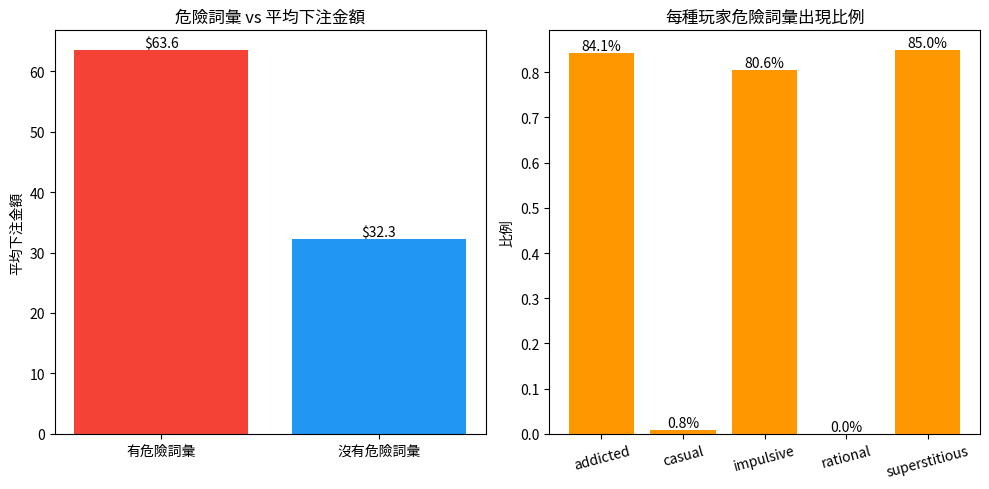

In [ ]:
# 定義危險詞彙
danger_words = ["翻本", "全押", "肯定", "加大", "贏回來", "一定"]

# 對每一筆 reasoning 檢查有沒有出現危險詞彙
def contains_danger_word(text):
    if pd.isna(text):
        return False
    return any(word in text for word in danger_words)

df_all["has_danger_word"] = df_all["reasoning"].apply(contains_danger_word)

# 比較有沒有出現危險詞彙時，下注金額的差異
danger_bet = df_all[df_all["has_danger_word"] == True]["bet"].mean()
normal_bet = df_all[df_all["has_danger_word"] == False]["bet"].mean()

print(f"出現危險詞彙時的平均下注：${danger_bet:.1f}")
print(f"沒有危險詞彙時的平均下注：${normal_bet:.1f}")
print(f"差異倍數：{danger_bet/normal_bet:.1f}x")

# 畫圖
plt.figure(figsize=(10, 5))

# 左圖：平均下注比較
plt.subplot(1, 2, 1)
bars = plt.bar(["有危險詞彙", "沒有危險詞彙"],
               [danger_bet, normal_bet],
               color=["#F44336", "#2196F3"])
plt.title("危險詞彙 vs 平均下注金額")
plt.ylabel("平均下注金額")
for bar, val in zip(bars, [danger_bet, normal_bet]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"${val:.1f}", ha="center", va="bottom")

# 右圖：每種玩家的危險詞彙出現比例
plt.subplot(1, 2, 2)
danger_rate = df_all.groupby("persona")["has_danger_word"].mean()
bars = plt.bar(danger_rate.index, danger_rate.values, color="#FF9800")
plt.title("每種玩家危險詞彙出現比例")
plt.ylabel("比例")
plt.xticks(rotation=15)
for bar, val in zip(bars, danger_rate.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{val:.1%}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### clustering group

In [ ]:
# 先把 cluster_name 和 is_high_value 合併進 df_all
df_all = df_all.merge(
    df_player[["player_id", "cluster_name", "is_high_value"]],
    on="player_id",
    how="left"
)

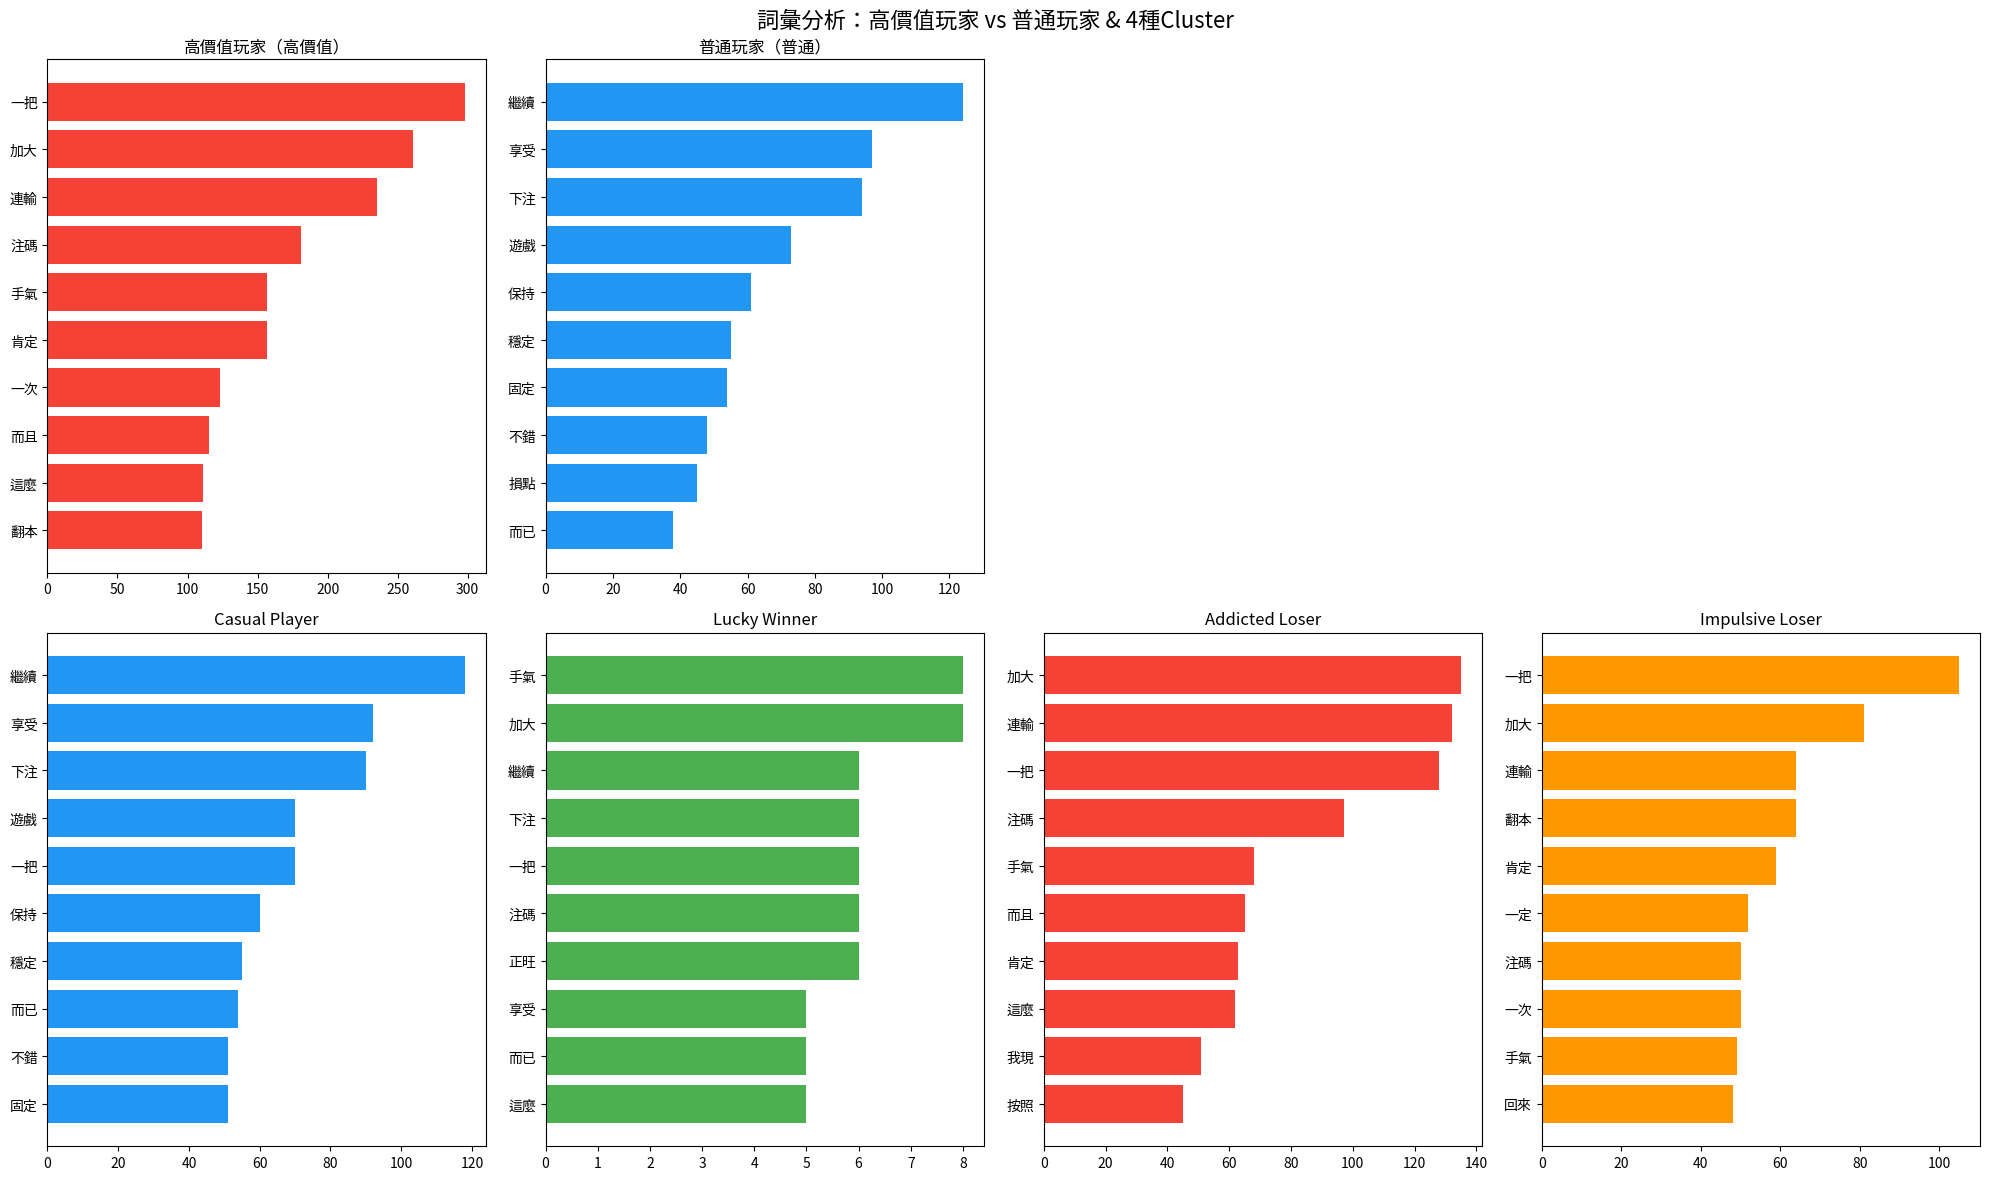

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
fig.suptitle("詞彙分析：高價值玩家 vs 普通玩家 & 4種Cluster", fontsize=16)

# ===== 第一排：高價值 vs 普通玩家 =====
for idx, (label, value) in enumerate([(("高價值玩家", 1), ("普通玩家", 0))][0]):
    subset = df_all[df_all["is_high_value"] == value]
    all_words = []
    for text in subset["reasoning"].dropna():
        words = jieba.cut(text)
        for word in words:
            if word not in stopwords and len(word) > 1:
                all_words.append(word)

    top_words = Counter(all_words).most_common(10)
    words_list, counts = zip(*top_words)

    color = "#F44336" if value == 1 else "#2196F3"
    axes[0][idx].barh(words_list, counts, color=color)
    axes[0][idx].set_title(f"{label}（{'高價值' if value==1 else '普通'}）")
    axes[0][idx].invert_yaxis()

# 把第一排後兩格關掉
axes[0][2].axis("off")
axes[0][3].axis("off")

# ===== 第二排：4種 Cluster =====
clusters = ["Casual Player", "Lucky Winner", "Addicted Loser", "Impulsive Loser"]
colors = ["#2196F3", "#4CAF50", "#F44336", "#FF9800"]

for idx, (cluster, color) in enumerate(zip(clusters, colors)):
    subset = df_all[df_all["cluster_name"] == cluster]
    all_words = []
    for text in subset["reasoning"].dropna():
        words = jieba.cut(text)
        for word in words:
            if word not in stopwords and len(word) > 1:
                all_words.append(word)

    top_words = Counter(all_words).most_common(10)
    words_list, counts = zip(*top_words)

    axes[1][idx].barh(words_list, counts, color=color)
    axes[1][idx].set_title(cluster)
    axes[1][idx].invert_yaxis()

plt.tight_layout()
plt.show()

*  洞察一： 危險詞彙出現時，下注金額是平常的 2 倍



* 洞察二： 破產前最後3局，「翻本」、「全押」、「肯定」是最強的預警訊號
* 洞察三： 高價值玩家 vs 普通玩家的語言模式完全不同，可以用詞彙來預測玩家類型
* 洞察四： 同樣說「加大」，Lucky Winner 是因為贏了順勢加注，Addicted Loser 是因為輸了追注——同一個詞在不同情境下意義完全不同

In [ ]:
import requests

url = "https://derrick-marshier-salvador.ngrok-free.dev/api/tags"
headers = {"ngrok-skip-browser-warning": "true"}

response = requests.get(url, headers=headers)
print(response.json())

{'models': [{'name': 'gemma3:27b', 'model': 'gemma3:27b', 'modified_at': '2026-04-07T12:58:46.231512722+08:00', 'size': 17396936941, 'digest': 'a418f5838eaf7fe2cfe0a3046c8384b68ba43a4435542c942f9db00a5f342203', 'details': {'parent_model': '', 'format': 'gguf', 'family': 'gemma3', 'families': ['gemma3'], 'parameter_size': '27.4B', 'quantization_level': 'Q4_K_M'}}]}
